# Kalman Filter — Current Prediction (Power Limiter / TV)

**Goal:** Predict motor current one step ahead (10 ms) for the TV algorithm with an 80 kW power limiter.

**State model (Constant Velocity):** `x = [I, dI/dt]`
- State equation:   `x(t+1) = F·x(t) + w`,  `w ~ N(0, Q)`
- Observation:      `z(t) = H·x(t) + v`,     `v ~ N(0, R)`

**Now:** 1 DC-bus current (fsp_endu_current.csv)  
**Target:** 4 per-motor currents — change `n_motors=4` when data is available

---
**VCU loop:** 100 Hz (dt = 10 ms)  
**CAN measurements:** ~47 Hz (dt ≈ 21 ms)  
→ Filter predicts every 10 ms, updates only when a CAN message arrives.

In [35]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Local paths ---
_cwd = Path().resolve()
if (_cwd / 'functions').exists():
    SRC_DIR = _cwd                      # Jupyter launched from src/
elif (_cwd / 'src' / 'functions').exists():
    SRC_DIR = _cwd / 'src'             # Jupyter launched from project root
else:
    raise FileNotFoundError(f'Could not find functions/ in {_cwd} or {_cwd}/src/')

DATA_DIR = SRC_DIR.parent / 'data' / 'model'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from functions.kalman_filter import (
    LinearKalmanFilter,
    make_constant_velocity_kf,
    make_cv_matrices,
)
from functions.evaluation import display_model_results

# --- Constants ---
DT_VCU        = 0.010          # VCU loop period [s]  (100 Hz)
POWER_LIMIT_W = 80_000         # FS power limit [W]
GAP_THRESHOLD = 0.100          # CAN gap threshold — treated as dropout [s]

print('Imports OK.')
print(f'SRC_DIR  : {SRC_DIR}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'Data file exists: {(DATA_DIR / "fsp_endu_current.csv").exists()}')

Imports OK.
SRC_DIR  : /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/src
DATA_DIR : /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/data/model
Data file exists: True


## 1. Data Loading and Exploration

In [36]:
# DC current + voltage
df_raw = pd.read_csv(DATA_DIR / 'fsp_endu_current.csv')
df_raw.columns = ['t', 'I_dc', 'U_raw']
df_raw['U_v']  = df_raw['U_raw'] / 10.0
df_raw['P_kw'] = df_raw['U_v'] * df_raw['I_dc'] / 1e3
df_raw = df_raw.sort_values('t').reset_index(drop=True)
df_raw['dt'] = df_raw['t'].diff().fillna(0)

# Motor torque setpoints (FR, RL, RR)
df_sp = pd.read_csv(DATA_DIR / 'setpoints.csv')
df_sp.columns = ['t', 'T_FR', 'T_RL', 'T_RR']

print(f"DC current  — samples: {len(df_raw):,},  duration: {df_raw['t'].max():.1f} s")
print(f"Setpoints   — samples: {len(df_sp):,},  duration: {df_sp['t'].max():.1f} s")
print(f"\nSetpoint ranges:")
print(f"  T_FR : {df_sp['T_FR'].min():.0f} .. {df_sp['T_FR'].max():.0f}")
print(f"  T_RL : {df_sp['T_RL'].min():.0f} .. {df_sp['T_RL'].max():.0f}")
print(f"  T_RR : {df_sp['T_RR'].min():.0f} .. {df_sp['T_RR'].max():.0f}")
print(f"\nI_DC range  : {df_raw['I_dc'].min():.0f} .. {df_raw['I_dc'].max():.0f} A")
print(f"Voltage     : {df_raw['U_v'].min():.1f} .. {df_raw['U_v'].max():.1f} V")
print(f"Peak power  : {df_raw['P_kw'].max():.1f} kW")
df_raw.head()

DC current  — samples: 27,099,  duration: 581.0 s
Setpoints   — samples: 58,102,  duration: 581.0 s

Setpoint ranges:
  T_FR : 0 .. 616
  T_RL : 0 .. 1137
  T_RR : 0 .. 1137

I_DC range  : -140 .. 1361 A
Voltage     : 475.0 .. 535.6 V
Peak power  : 657.6 kW


,t,I_dc,U_raw,U_v,P_kw,dt
0,0.010176,0,5356,535.6,0.0,0.000000
1,0.029893,0,5356,535.6,0.0,0.019718
2,0.049786,0,5356,535.6,0.0,0.019893
3,0.074339,0,5356,535.6,0.0,0.024553
4,0.093902,0,5356,535.6,0.0,0.019563


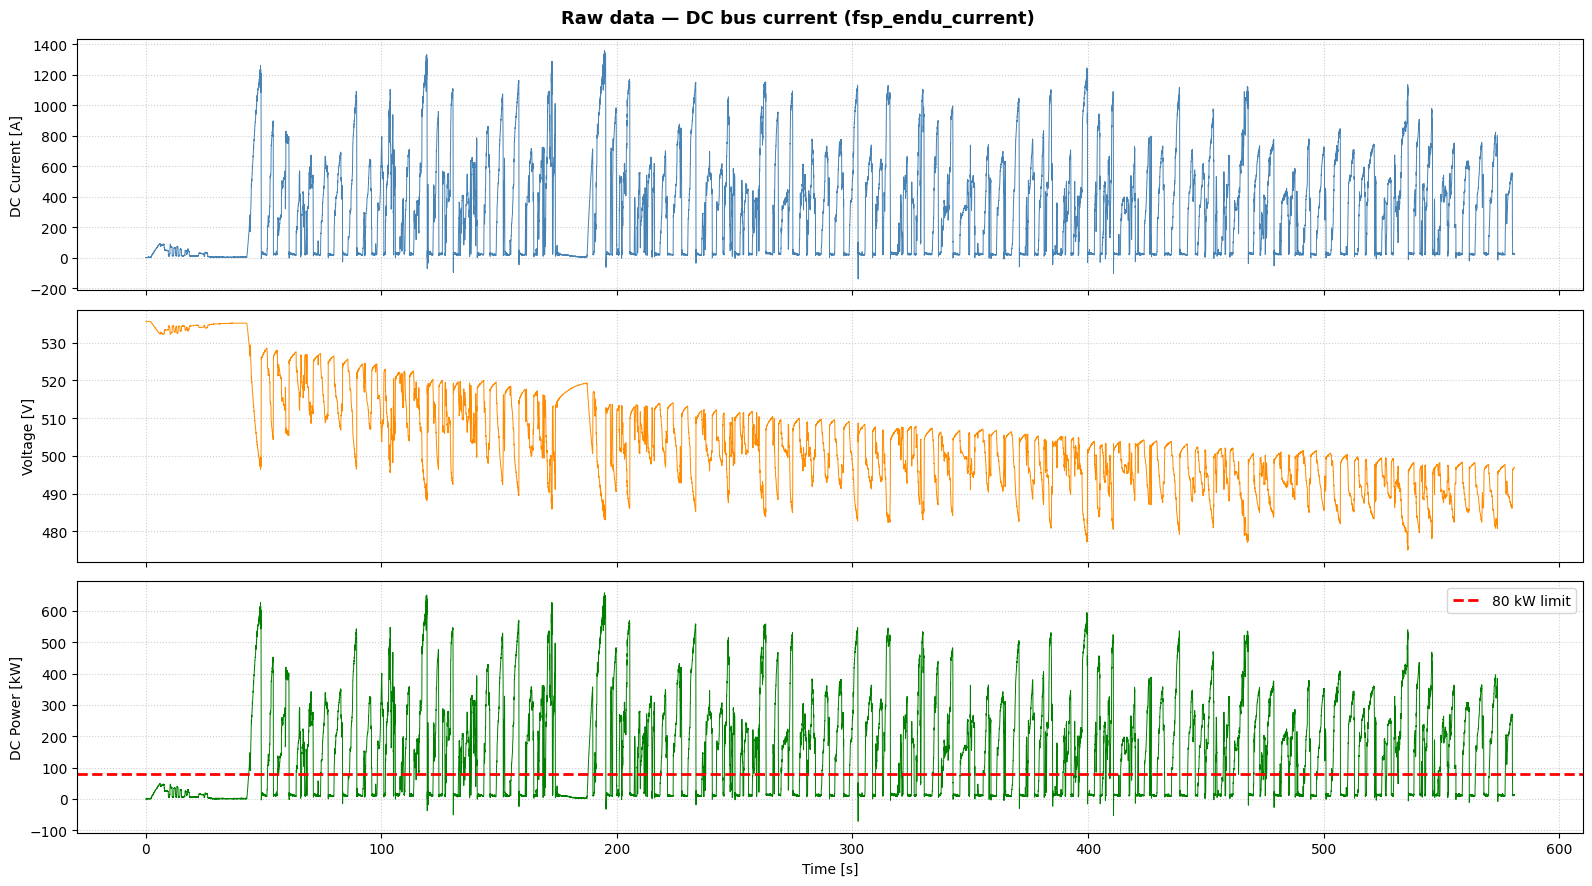

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Raw data — DC bus current (fsp_endu_current)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(df_raw['t'], df_raw['I_dc'], lw=0.7, color='steelblue')
ax.set_ylabel('DC Current [A]')
ax.grid(True, ls=':', alpha=0.6)

ax = axes[1]
ax.plot(df_raw['t'], df_raw['U_v'], lw=0.7, color='darkorange')
ax.set_ylabel('Voltage [V]')
ax.grid(True, ls=':', alpha=0.6)

ax = axes[2]
ax.plot(df_raw['t'], df_raw['P_kw'], lw=0.7, color='green')
ax.axhline(80, color='red', ls='--', lw=2, label='80 kW limit')
ax.set_ylabel('DC Power [kW]')
ax.set_xlabel('Time [s]')
ax.legend()
ax.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 2. Preprocessing

VCU runs at 100 Hz (dt = 10 ms), CAN delivers measurements every ~21 ms.  
Resample data to a 10 ms grid and mark which ticks have a real CAN measurement.

In [38]:
# Detect continuous segments (CAN dropout > GAP_THRESHOLD)
df_raw['segment'] = (df_raw['dt'] > GAP_THRESHOLD).cumsum()
seg_stats = df_raw.groupby('segment')['t'].agg(['min', 'max', 'count'])
seg_stats['duration_s'] = seg_stats['max'] - seg_stats['min']
print(f"Continuous segments: {len(seg_stats)}")
print(seg_stats.to_string())

# VCU 10 ms grid
t_vcu = np.arange(df_raw['t'].min(), df_raw['t'].max(), DT_VCU)

df_vcu = pd.DataFrame({'t': t_vcu})
df_vcu['I_dc'] = np.interp(t_vcu, df_raw['t'].values, df_raw['I_dc'].values)
df_vcu['U_v']  = np.interp(t_vcu, df_raw['t'].values, df_raw['U_v'].values)

# Resample setpoints to VCU grid (linear interpolation)
for col in ['T_FR', 'T_RL', 'T_RR']:
    df_vcu[col] = np.interp(t_vcu, df_sp['t'].values, df_sp[col].values)

# Total torque setpoint — main control input (cross-corr peak with I_dc at lag≈50 ms)
df_vcu['T_sum'] = df_vcu['T_FR'] + df_vcu['T_RL'] + df_vcu['T_RR']

# Mark VCU ticks that coincide with a real CAN message (tolerance 2 ms)
can_times = df_raw['t'].values
TOL = 0.002
df_vcu['is_measured'] = [np.any(np.abs(can_times - t) < TOL) for t in t_vcu]

print(f"\nVCU ticks (10 ms)       : {len(df_vcu):,}")
print(f"With CAN measurement    : {df_vcu['is_measured'].sum():,}  ({100*df_vcu['is_measured'].mean():.1f}%)")
print(f"Predict-only ticks      : {(~df_vcu['is_measured']).sum():,}  ({100*(~df_vcu['is_measured']).mean():.1f}%)")
print(f"T_sum range             : {df_vcu['T_sum'].min():.0f} .. {df_vcu['T_sum'].max():.0f}")
print(f"corr(I_dc, T_sum)       : {df_vcu['I_dc'].corr(df_vcu['T_sum']):.4f}")

Continuous segments: 1
              min         max  count  duration_s
segment                                         
0        0.010176  580.992215  27099  580.982039

VCU ticks (10 ms)       : 58,099
With CAN measurement    : 10,699  (18.4%)
Predict-only ticks      : 47,400  (81.6%)
T_sum range             : 0 .. 2890
corr(I_dc, T_sum)       : 0.9488


## 3. KF Parameter Estimation

- **R** (measurement noise) — variance of high-frequency current fluctuations  
- **q_accel** (process noise) — how fast the current derivative changes  

Estimated from training data (first 70%).

Kalman Filter Parameters
VCU dt        : 10 ms
R (variance)  : 11.61 A²
R (std)       : 3.41 A
q_accel       : 37918.89 A/s²


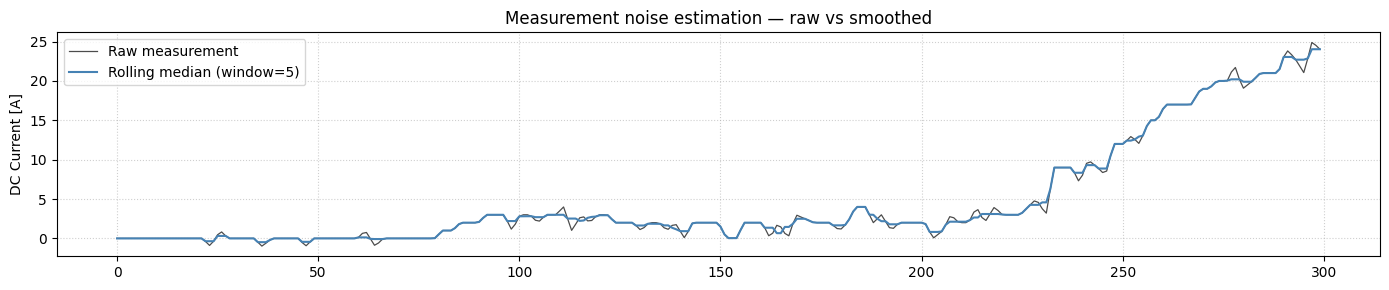

In [39]:
TRAIN_FRAC = 0.70
n_train = int(len(df_vcu) * TRAIN_FRAC)

df_train = df_vcu.iloc[:n_train].reset_index(drop=True)
df_test  = df_vcu.iloc[n_train:].reset_index(drop=True)

I_train = df_train['I_dc'].values

# --- Measurement noise R ---
# Subtract rolling median (window=5) — residual approximates sensor noise
window = 5
I_smooth = pd.Series(I_train).rolling(window, center=True, min_periods=1).median().values
noise_residuals = I_train - I_smooth
R_std  = np.std(noise_residuals)
R_var  = R_std ** 2

# --- Process noise q_accel ---
# Second differences / dt² ≈ acceleration; 75th percentile gives a robust estimate
d2I = np.diff(I_train, n=2) / (DT_VCU ** 2)
q_accel = float(np.percentile(np.abs(d2I), 75))

print("=" * 40)
print("Kalman Filter Parameters")
print("=" * 40)
print(f"VCU dt        : {DT_VCU*1000:.0f} ms")
print(f"R (variance)  : {R_var:.2f} A²")
print(f"R (std)       : {R_std:.2f} A")
print(f"q_accel       : {q_accel:.2f} A/s²")
print("=" * 40)

# Preview smoothing quality
fig, ax = plt.subplots(figsize=(14, 3))
n_preview = 300
ax.plot(I_train[:n_preview], lw=0.9, label='Raw measurement', color='black', alpha=0.7)
ax.plot(I_smooth[:n_preview], lw=1.5, label='Rolling median (window=5)', color='steelblue')
ax.set_title('Measurement noise estimation — raw vs smoothed')
ax.set_ylabel('DC Current [A]')
ax.legend()
ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 3b. 3-State EKF with Commanded Current I_cmd

**Why plain B·u at lag=0 failed:** the cross-correlation between setpoints and DC current peaks at lag≈50 ms — AMK motors have a time constant τ≈50 ms. Adding u(t) to predict I(t+1) is useless because the setpoint only "arrives" at the current at I(t+5).

**Solution — augmented state `x = [I_dc, dI/dt, I_cmd]`:**

```
I_dc(t+1)  =  I_dc(t)  +  dt · dI/dt(t)                        # kinematics (CV)
dI/dt(t+1) =  dI/dt(t) +  γ·dt · (I_cmd(t) − I_dc(t))         # pulled toward I_cmd
I_cmd(t+1) =  (1−α) · I_cmd(t) + α·k_sp · T_sum(t)            # IIR filter of setpoints
```

Parameters:
- `τ = 50 ms` → `α = dt/τ = 0.2` (setpoint IIR filter rate)
- `γ = 1/τ` (I_cmd → dI/dt coupling gain)
- `k_sp` — steady-state gain estimated from data [A / T_sum unit]

All matrices F, B, H are constant → still a **linear** filter (EKF label used by convention).

In [40]:
T_sum_train = df_train['T_sum'].values
I_t = df_train['I_dc'].values

# --- Time constant from cross-correlation peak ≈ 50 ms ---
tau_motor = 0.050                    # [s]
alpha     = DT_VCU / tau_motor       # setpoint IIR filter coefficient (= 0.2)
gamma     = 1.0 / tau_motor          # I_cmd → dI/dt coupling gain [1/s]

# --- k_sp: steady-state setpoint-to-current gain (quasi-static operating points) ---
dI_train = np.abs(np.gradient(I_t, DT_VCU))
mask_qs  = (T_sum_train > 200) & (dI_train < 300)   # active driving, slow changes
if mask_qs.sum() > 50:
    k_sp = float(np.median(I_t[mask_qs] / T_sum_train[mask_qs]))
else:
    k_sp = float(np.corrcoef(T_sum_train, I_t)[0, 1]
                 * np.std(I_t) / np.std(T_sum_train))
k_sp = max(k_sp, 0.05)              # guard against negative gain

# --- State transition matrix F (3×3) ---
F3 = np.array([
    [1.0,              DT_VCU,        0.0         ],   # I_dc row
    [-gamma * DT_VCU,  1.0,           gamma*DT_VCU],   # dI/dt row
    [0.0,              0.0,           1.0 - alpha ],   # I_cmd row
])

# --- Control input matrix B (3×1) — input: T_sum ---
B3 = np.array([[0.0],
               [0.0],
               [alpha * k_sp]])

# --- Observation matrix H (1×3) — only I_dc is measured ---
H3 = np.array([[1.0, 0.0, 0.0]])

# --- Process noise covariance Q (3×3) ---
q2 = q_accel ** 2
Q3 = np.array([
    [q2 * DT_VCU**3 / 3.0,  q2 * DT_VCU**2 / 2.0,  0.0                     ],
    [q2 * DT_VCU**2 / 2.0,  q2 * DT_VCU,            0.0                     ],
    [0.0,                    0.0,                     (k_sp * alpha * 300)**2 ],
])

print("=" * 52)
print("3-State EKF Parameters")
print("=" * 52)
print(f"  τ  (motor time constant)      : {tau_motor*1000:.0f} ms")
print(f"  α  (setpoint IIR coefficient) : {alpha:.3f}")
print(f"  γ  (I_cmd → dI/dt coupling)  : {gamma:.1f} 1/s")
print(f"  k_sp (A / T_sum unit)         : {k_sp:.4f}")
print(f"  Quasi-static samples          : {mask_qs.sum():,} ({100*mask_qs.mean():.1f}%)")
print()
print("State transition matrix F:")
print(np.round(F3, 4))
print("\nControl input matrix B:")
print(np.round(B3, 6))
print("\nObservation matrix H:", H3)

3-State EKF Parameters
  τ  (motor time constant)      : 50 ms
  α  (setpoint IIR coefficient) : 0.200
  γ  (I_cmd → dI/dt coupling)  : 20.0 1/s
  k_sp (A / T_sum unit)         : 0.2842
  Quasi-static samples          : 12,234 (30.1%)

State transition matrix F:
[[ 1.    0.01  0.  ]
 [-0.2   1.    0.2 ]
 [ 0.    0.    0.8 ]]

Control input matrix B:
[[0.      ]
 [0.      ]
 [0.056834]]

Observation matrix H: [[1. 0. 0.]]


## 4. Filter Setup and VCU Loop Simulation

Two filters run in parallel for comparison:

| Filter | States | Control input |
|--------|--------|---------------|
| **Baseline CV** | `[I_dc, dI/dt]` | none |
| **EKF 3-state** | `[I_dc, dI/dt, I_cmd]` | `T_sum` (total torque setpoint) |

Recorded per tick:
- `x_pred_base / x_pred_ekf` — 1-step-ahead prediction `x̂(t+1|t)` fed to the TV / power limiter
- `x_pred_std` — prediction std from covariance P (used for +2σ safety margin)
- `x_cmd_est` — I_cmd state trace (diagnostics)

In [41]:
I_test   = df_test['I_dc'].values
is_meas  = df_test['is_measured'].values
T_sum_t  = df_test['T_sum'].values
N        = len(df_test)

I0     = df_test['I_dc'].iloc[0]
I_cmd0 = k_sp * T_sum_t[0]
x0_2   = np.array([I0, 0.0])
P0_2   = np.diag([R_var, (q_accel * DT_VCU) ** 2])
x0_3   = np.array([I0, 0.0, I_cmd0])
P0_3   = np.diag([R_var, (q_accel * DT_VCU) ** 2, (k_sp * 300) ** 2])

# --- Filter 1: baseline CV (2 states, no setpoints) ---
kf_base = make_constant_velocity_kf(
    dt=DT_VCU, r_noise=R_std, q_accel=q_accel, n_motors=1, x0=x0_2, P0=P0_2,
)

# --- Filter 2: EKF 3-state [I_dc, dI/dt, I_cmd] ---
kf_ekf = LinearKalmanFilter(F=F3, H=H3, Q=Q3, R=np.array([[R_var]]), B=B3,
                             x0=x0_3, P0=P0_3)

x_pred_base = np.zeros(N)
x_pred_ekf  = np.zeros(N)
x_pred_std  = np.zeros(N)
x_cmd_est   = np.zeros(N)   # I_cmd state trace (diagnostics)

t0 = time.perf_counter()
for i in range(N):
    u_i = np.array([T_sum_t[i]])

    # 1-step-ahead prediction (output to TV / power limiter)
    x_pred_base[i] = kf_base.predict_k_ahead(k=1)[0]
    x_pred_ekf[i]  = kf_ekf.predict_k_ahead(k=1, u_sequence=[u_i])[0]
    x_pred_std[i]  = kf_ekf.estimate_std()[0]

    # Prediction step
    kf_base.predict()
    kf_ekf.predict(u=u_i)

    # Update when a CAN measurement is available
    if is_meas[i]:
        z = np.array([I_test[i]])
        kf_base.update(z)
        kf_ekf.update(z)

    x_cmd_est[i] = kf_ekf.state[2]   # I_cmd state estimate

t_sim = time.perf_counter() - t0
print(f"Simulation complete ({N:,} ticks, {t_sim*1000:.1f} ms).")
print(f"Time/tick : {t_sim/N*1e6:.2f} µs  →  {N/t_sim:.0f} Hz  (VCU requirement: ≥100 Hz)")

Simulation complete (17,430 ticks, 316.3 ms).
Time/tick : 18.15 µs  →  55104 Hz  (VCU requirement: ≥100 Hz)


## 5. Evaluation of 1-Step-Ahead Prediction

── Baseline: CV 2-state ─────────────────────────────
  WYNIKI MODELU: KF CV — baseline
  R2 (łącznie)    : 0.8069
  RMSE            : 123.48 A
  MAE             : 51.36 A
  MedAE           : 17.12 A
  MAPE            : 81.47 %
  R2 per silnik   : I_DC=0.807
--------------------------------------------------------
  Niedoszacowania : 51.8 % próbek
  Śr. niedoszac.  : 52.55 A   (kierunek groźny!)
--------------------------------------------------------
  Moc RMSE        : 61.17 kW
  Realne przekr.  : 10577 zdarzeń > 80 kW
  Przeoczone (FN) : 456   <- KRYTYCZNE
  Zbędne cięcia FP: 328
  Recall przekr.  : 95.7 %
--------------------------------------------------------
  Czas/próbkę     : 0.0033 ms
  Częstotliwość   : 300124.9 Hz



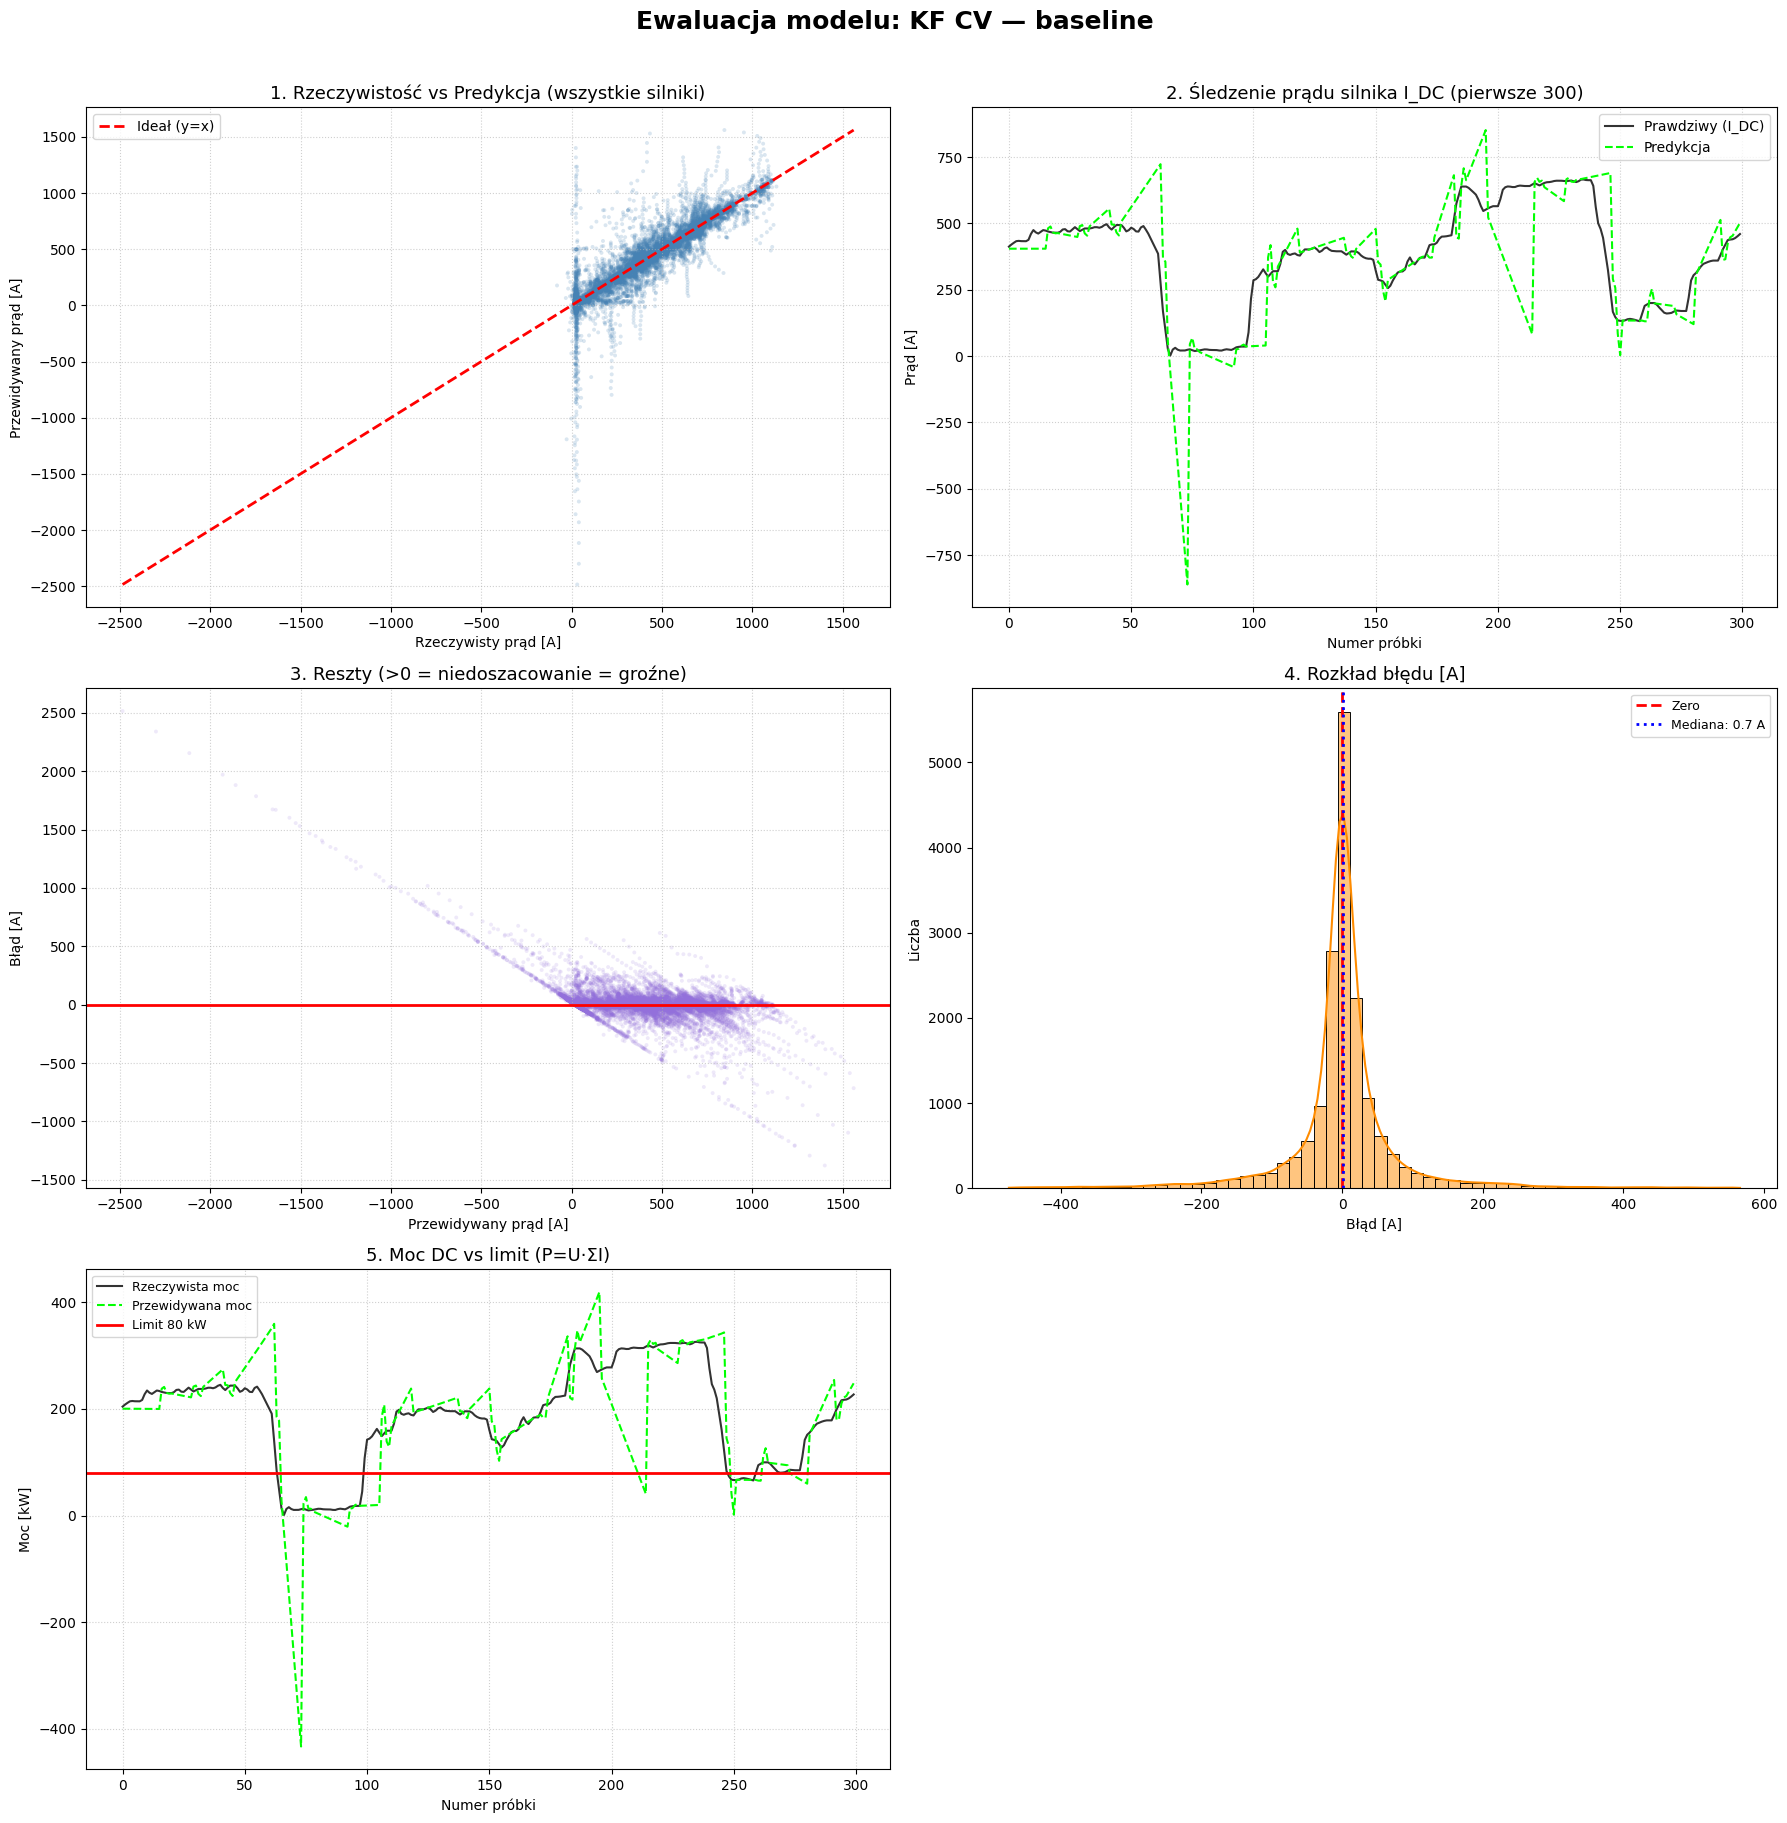

── EKF 3-state [I_dc, dI/dt, I_cmd] ────────────────
  WYNIKI MODELU: EKF 3-state + I_cmd
  R2 (łącznie)    : 0.8191
  RMSE            : 119.51 A
  MAE             : 50.49 A
  MedAE           : 17.24 A
  MAPE            : 79.63 %
  R2 per silnik   : I_DC=0.819
--------------------------------------------------------
  Niedoszacowania : 53.4 % próbek
  Śr. niedoszac.  : 52.20 A   (kierunek groźny!)
--------------------------------------------------------
  Moc RMSE        : 59.19 kW
  Realne przekr.  : 10577 zdarzeń > 80 kW
  Przeoczone (FN) : 440   <- KRYTYCZNE
  Zbędne cięcia FP: 326
  Recall przekr.  : 95.8 %
--------------------------------------------------------
  Czas/próbkę     : 0.0033 ms
  Częstotliwość   : 300124.9 Hz



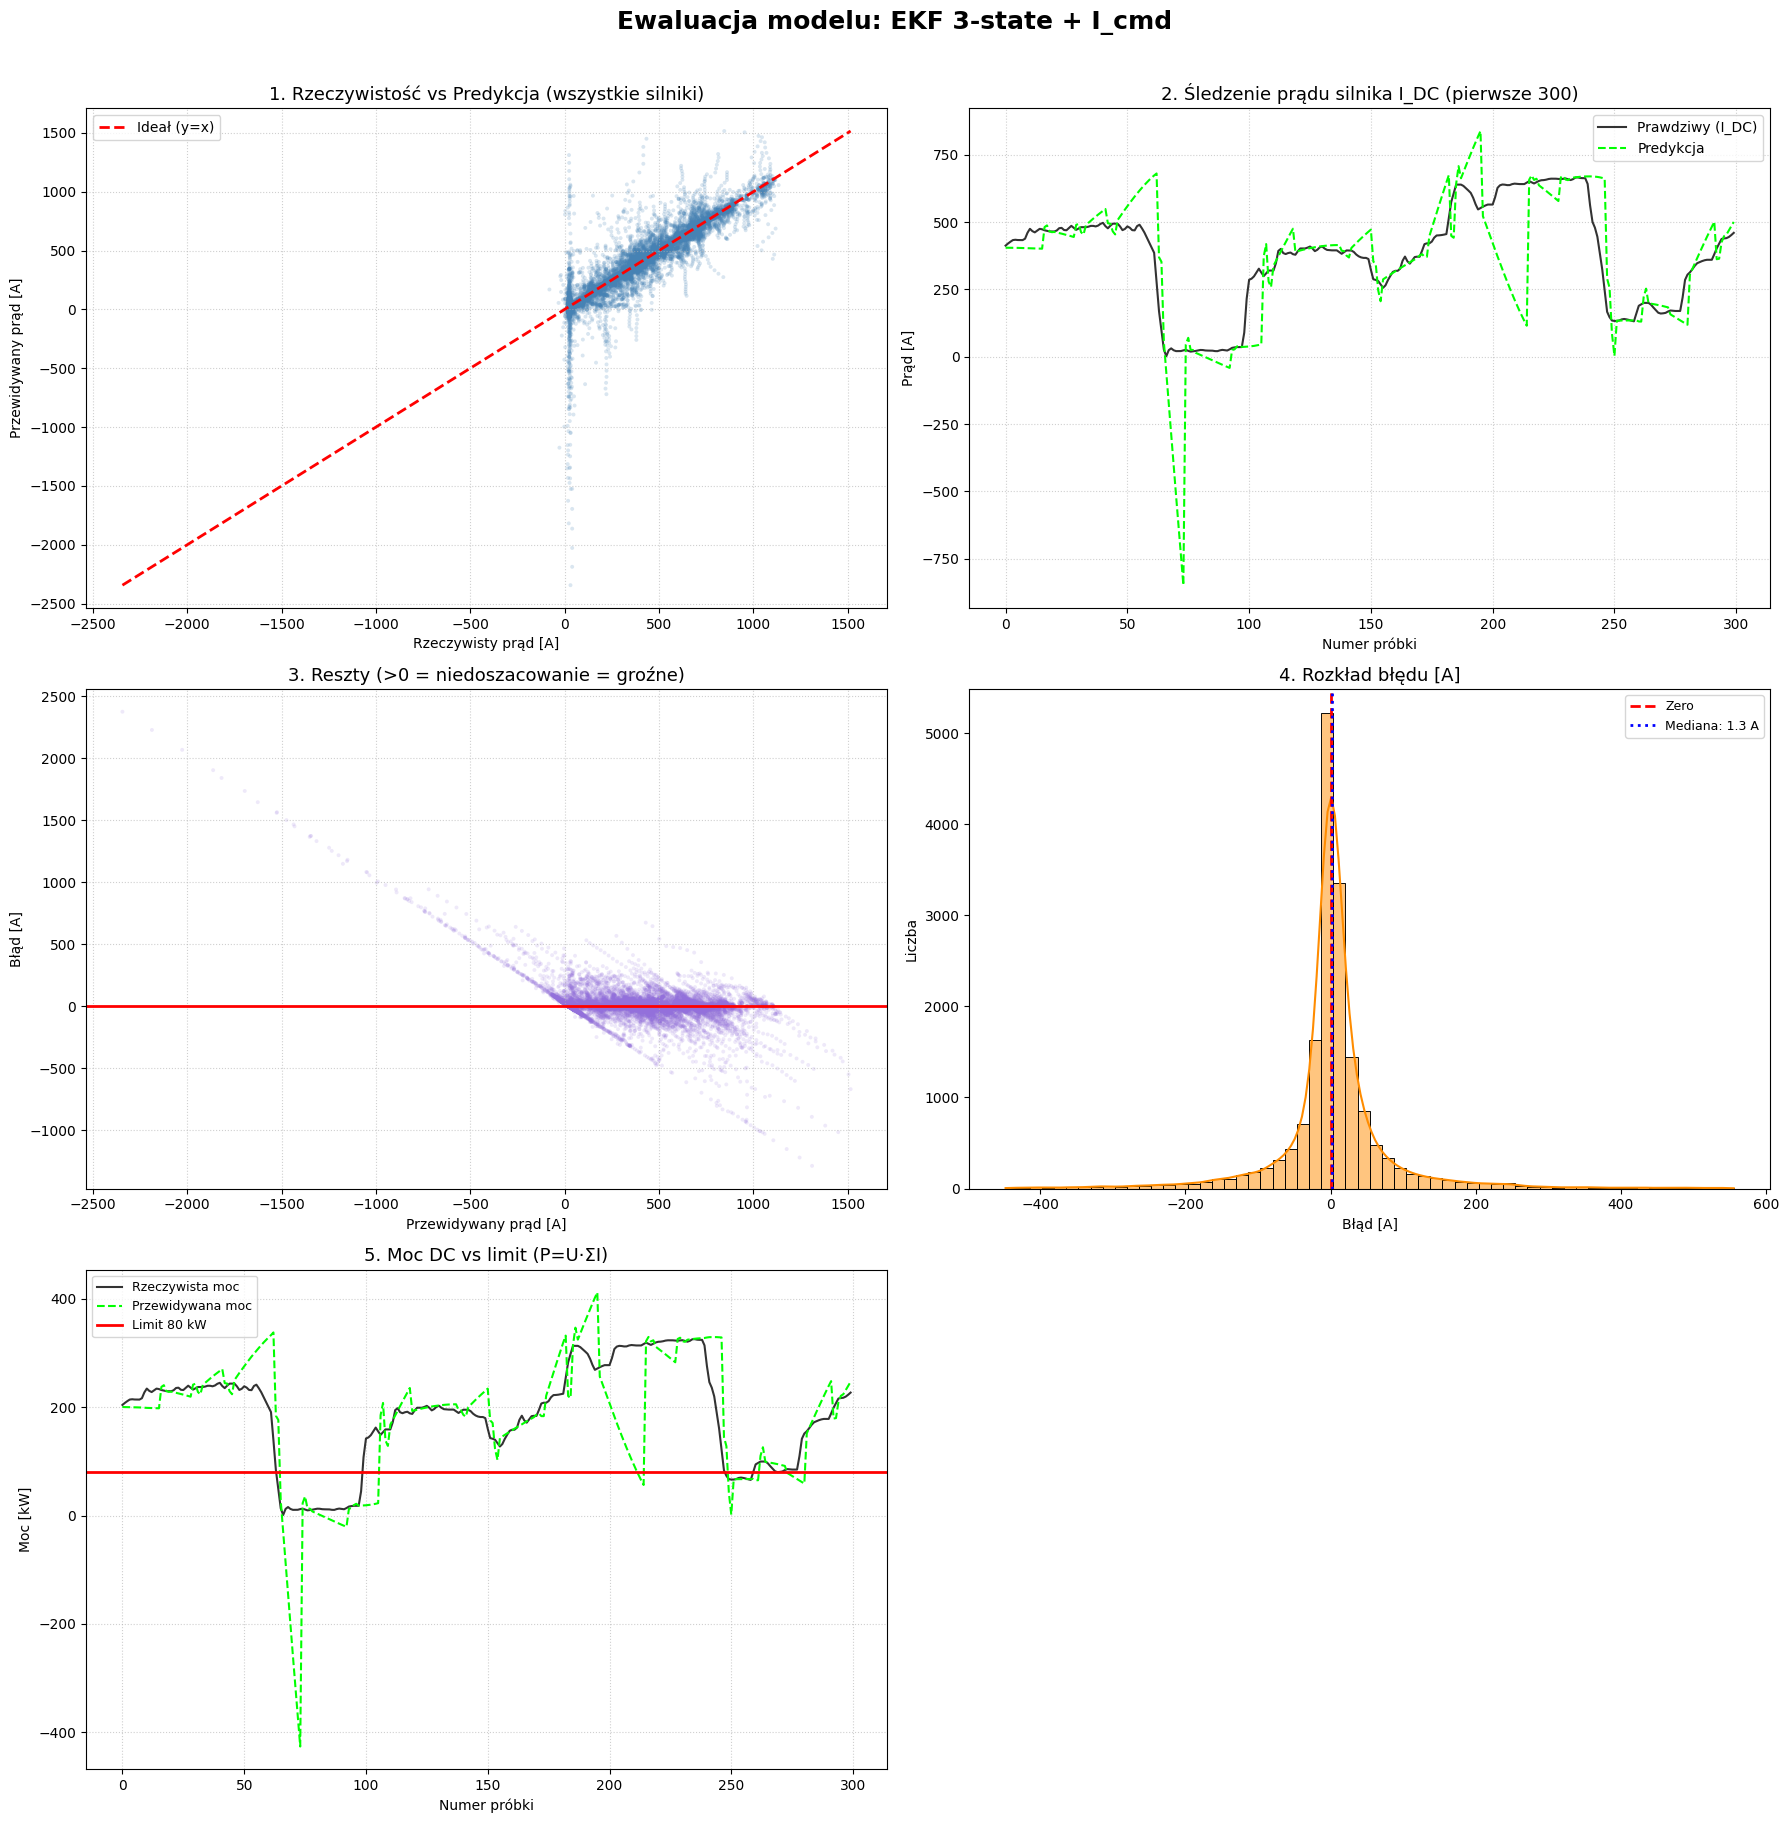

  SUMMARY
  RMSE [A]                 baseline=123.47847740210625  EKF=119.50690173701553  (+3.2%)
  MAE [A]                  baseline=51.3614882192322  EKF=50.490556361930814  (+1.7%)
  Underpred. [%]           baseline=nan       EKF=nan       (+nan%)
  FN (missed)              baseline=nan       EKF=nan     
  Violation recall [%]     baseline=nan       EKF=nan     


In [42]:
y_true = I_test[1:]
U_eval = df_test['U_v'].values[1:]

t0 = time.perf_counter()
for _ in range(N):
    kf_ekf.predict_k_ahead(k=1, u_sequence=[np.array([T_sum_t[0]])])
t_infer = time.perf_counter() - t0

print("── Baseline: CV 2-state ─────────────────────────────")
m_base = display_model_results(
    'KF CV — baseline', y_true, x_pred_base[:-1],
    t_infer, voltage=U_eval, motor_names=['I_DC'], save_to_excel=False,
)

print("── EKF 3-state [I_dc, dI/dt, I_cmd] ────────────────")
m_ekf = display_model_results(
    'EKF 3-state + I_cmd', y_true, x_pred_ekf[:-1],
    t_infer, voltage=U_eval, motor_names=['I_DC'], save_to_excel=False,
)

print("=" * 52)
print("  SUMMARY")
print("=" * 52)
for key in ['RMSE [A]', 'MAE [A]', 'Underpred. [%]', 'FN (missed)', 'Violation recall [%]']:
    b = m_base.get(key, float('nan'))
    c = m_ekf.get(key, float('nan'))
    if isinstance(b, float) and b != 0 and key not in ('FN (missed)', 'Violation recall [%]'):
        delta = f"  ({100*(b-c)/b:+.1f}%)"
    else:
        delta = ""
    print(f"  {key:<24} baseline={b!s:<8}  EKF={c!s:<8}{delta}")
print("=" * 52)

## 6. Visualization

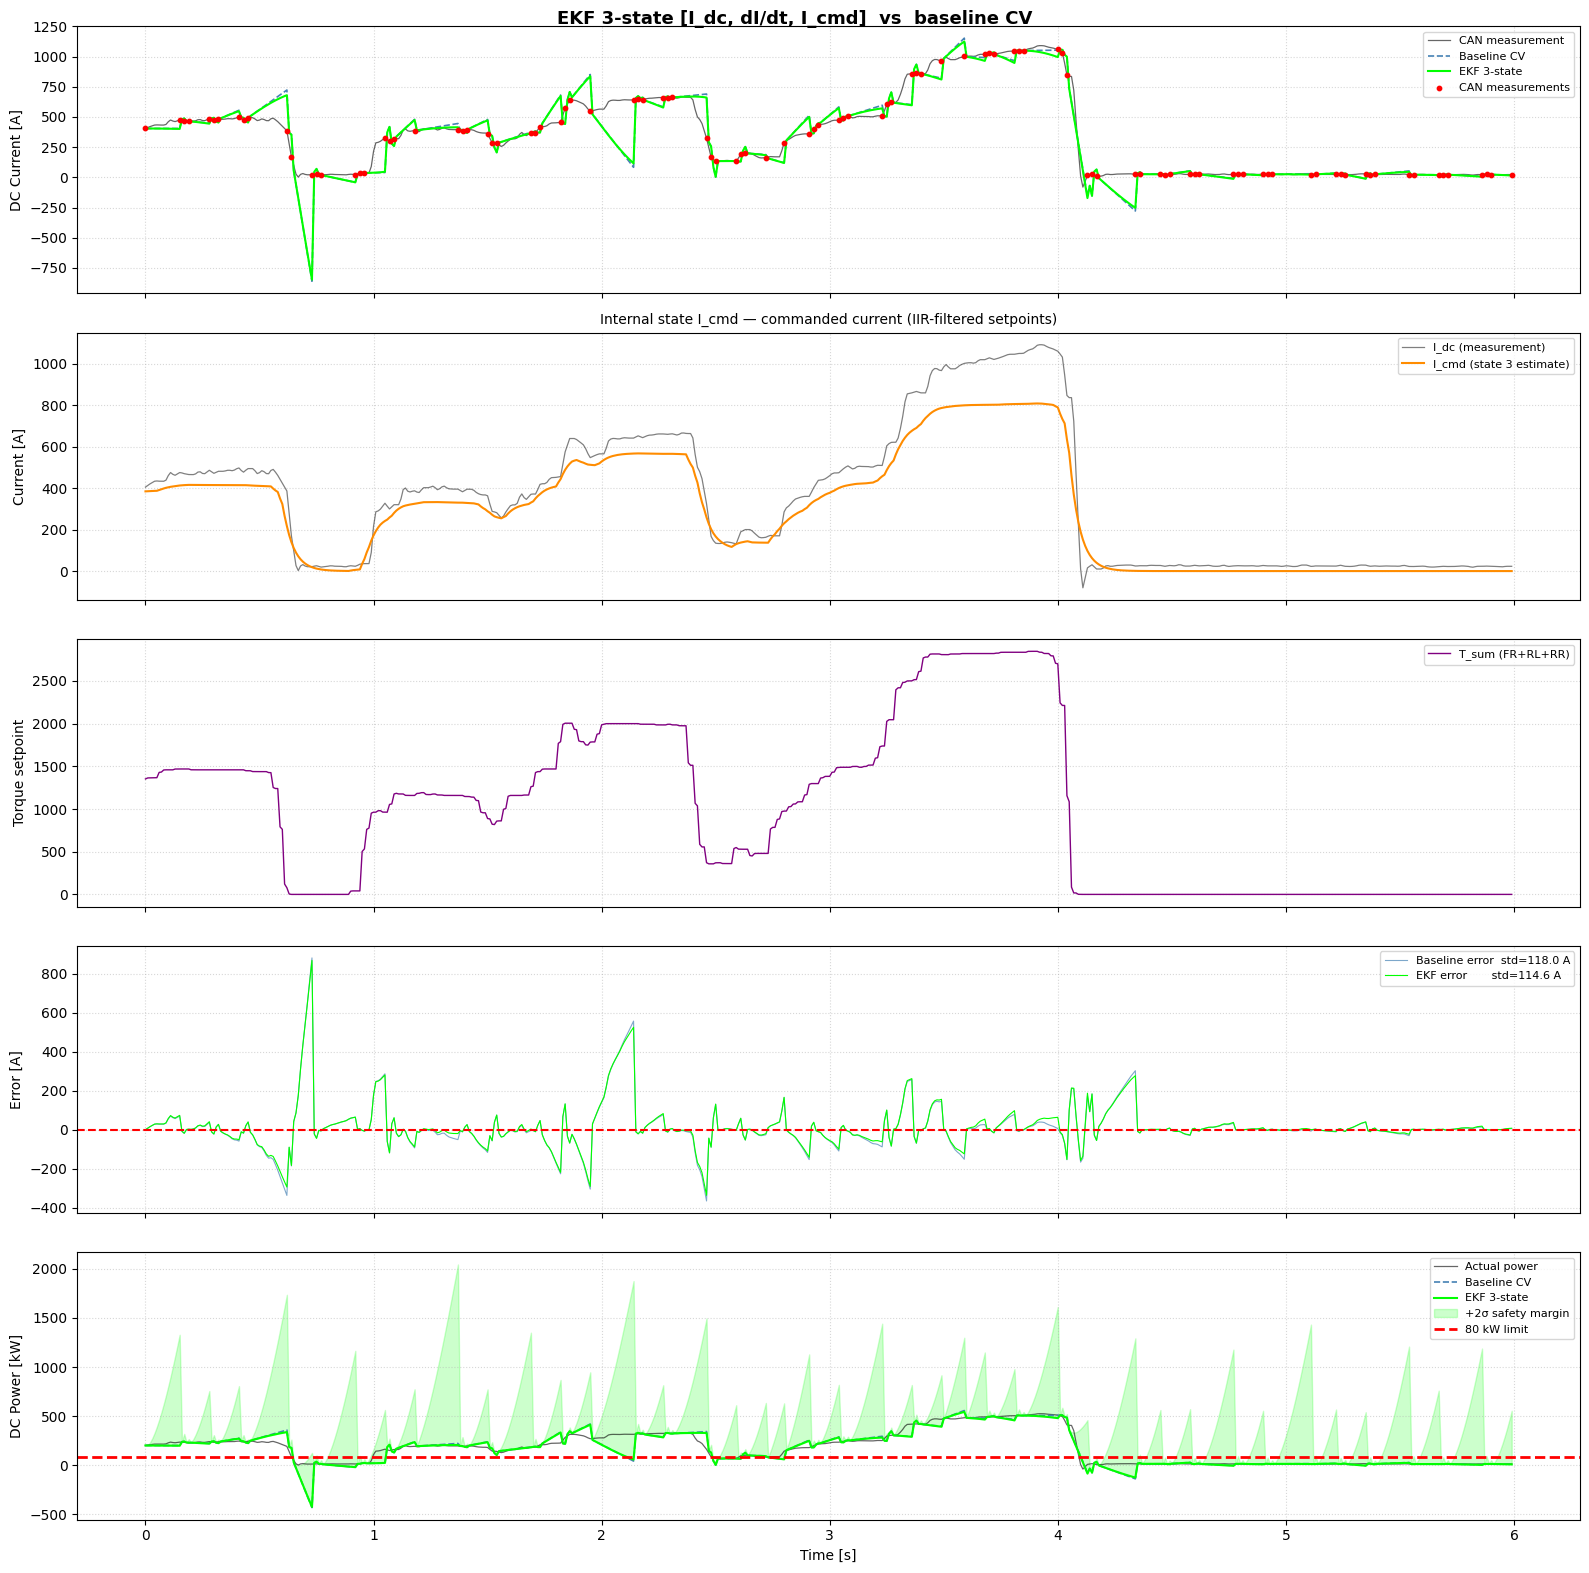

In [43]:
N_PLOT = 600
sl = slice(0, N_PLOT)
t_plot = df_test['t'].values[sl] - df_test['t'].values[0]

fig, axes = plt.subplots(5, 1, figsize=(16, 16), sharex=True)
fig.suptitle('EKF 3-state [I_dc, dI/dt, I_cmd]  vs  baseline CV', fontsize=13, fontweight='bold')

# Panel 1: measurement + predictions
ax = axes[0]
ax.plot(t_plot, I_test[sl],       lw=0.9, color='black',     alpha=0.6, label='CAN measurement')
ax.plot(t_plot, x_pred_base[sl],  lw=1.2, color='steelblue', ls='--',   label='Baseline CV')
ax.plot(t_plot, x_pred_ekf[sl],   lw=1.5, color='lime',                 label='EKF 3-state')
meas_idx = np.where(is_meas[sl])[0]
ax.scatter(t_plot[meas_idx], I_test[sl][meas_idx], color='red', s=10, zorder=5, label='CAN measurements')
ax.set_ylabel('DC Current [A]')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, ls=':', alpha=0.5)

# Panel 2: I_cmd vs I_dc — internal state diagnostics
ax = axes[1]
ax.plot(t_plot, I_test[sl],    lw=0.9, color='black',      alpha=0.5, label='I_dc (measurement)')
ax.plot(t_plot, x_cmd_est[sl], lw=1.5, color='darkorange',            label='I_cmd (state 3 estimate)')
ax.set_ylabel('Current [A]')
ax.set_title('Internal state I_cmd — commanded current (IIR-filtered setpoints)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.5)

# Panel 3: torque setpoints
ax = axes[2]
ax.plot(t_plot, df_test['T_sum'].values[sl], lw=1.0, color='purple', label='T_sum (FR+RL+RR)')
ax.set_ylabel('Torque setpoint')
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.5)

# Panel 4: prediction error
ax = axes[3]
err_base = I_test[sl] - x_pred_base[sl]
err_ekf  = I_test[sl] - x_pred_ekf[sl]
ax.plot(t_plot, err_base, lw=0.8, color='steelblue', alpha=0.7, label=f'Baseline error  std={np.std(err_base):.1f} A')
ax.plot(t_plot, err_ekf,  lw=0.8, color='lime',                 label=f'EKF error       std={np.std(err_ekf):.1f} A')
ax.axhline(0, color='red', lw=1.5, ls='--')
ax.set_ylabel('Error [A]')
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.5)

# Panel 5: DC power vs limit
ax = axes[4]
U_sl   = df_test['U_v'].values[sl]
P_true = U_sl * I_test[sl] / 1e3
P_base = U_sl * x_pred_base[sl] / 1e3
P_ekf  = U_sl * x_pred_ekf[sl] / 1e3
ax.plot(t_plot, P_true, lw=0.9, color='black',     alpha=0.6, label='Actual power')
ax.plot(t_plot, P_base, lw=1.2, color='steelblue', ls='--',   label='Baseline CV')
ax.plot(t_plot, P_ekf,  lw=1.5, color='lime',                 label='EKF 3-state')
ax.fill_between(t_plot, P_ekf,
                U_sl * (x_pred_ekf[sl] + 2*x_pred_std[sl]) / 1e3,
                alpha=0.2, color='lime', label='+2σ safety margin')
ax.axhline(80, color='red', lw=2, ls='--', label='80 kW limit')
ax.set_ylabel('DC Power [kW]')
ax.set_xlabel('Time [s]')
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Tuning — Effect of Q and R Parameters

The Kalman Filter has two key tuning parameters:
- **Large Q / small R** → filter trusts measurements, reacts fast, noisier output
- **Small Q / large R** → filter trusts the model, reacts slowly, smoother output

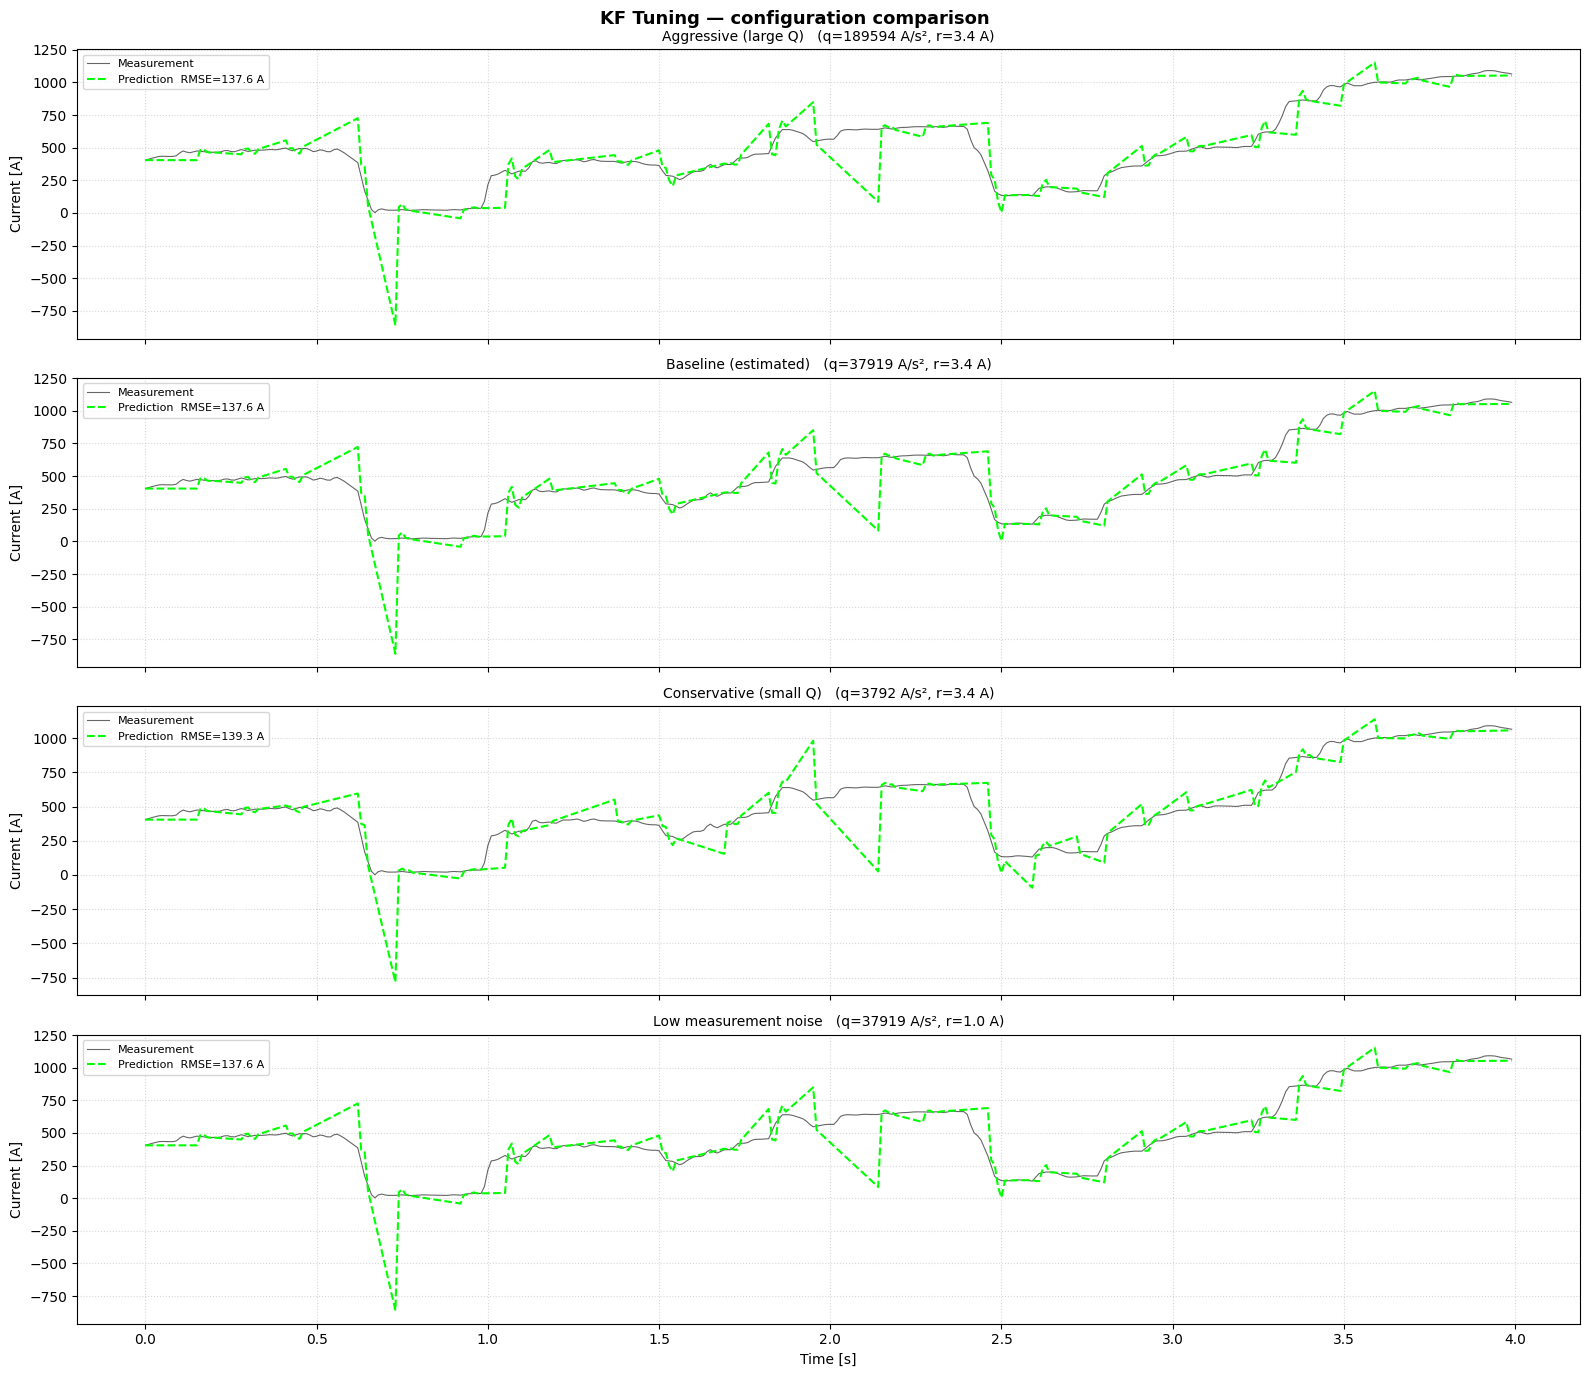

In [44]:
configs = [
    ('Aggressive (large Q)',    q_accel * 5,   R_std),
    ('Baseline (estimated)',    q_accel,        R_std),
    ('Conservative (small Q)', q_accel * 0.1,  R_std),
    ('Low measurement noise',  q_accel,         R_std * 0.3),
]

N_COMP = min(400, len(df_test))
sl_c   = slice(0, N_COMP)
t_c    = df_test['t'].values[sl_c] - df_test['t'].values[0]

fig, axes = plt.subplots(len(configs), 1, figsize=(16, 3.5 * len(configs)), sharex=True)
fig.suptitle('KF Tuning — configuration comparison', fontsize=13, fontweight='bold')

for ax, (name, q, r) in zip(axes, configs):
    kf_c = make_constant_velocity_kf(
        dt=DT_VCU, r_noise=r, q_accel=q, n_motors=1,
        x0=np.array([I_test[0], 0.0]),
        P0=np.diag([r**2, (q * DT_VCU)**2]),
    )
    preds_c = np.zeros(N_COMP)
    for i in range(N_COMP):
        preds_c[i] = kf_c.predict_k_ahead(k=1)[0]
        kf_c.predict()
        if is_meas[i]:
            kf_c.update(np.array([I_test[i]]))

    rmse = np.sqrt(np.mean((I_test[sl_c] - preds_c) ** 2))
    ax.plot(t_c, I_test[sl_c], lw=0.8, color='black', alpha=0.6, label='Measurement')
    ax.plot(t_c, preds_c,      lw=1.5, color='lime',  ls='--',   label=f'Prediction  RMSE={rmse:.1f} A')
    ax.set_ylabel('Current [A]')
    ax.set_title(f'{name}   (q={q:.0f} A/s², r={r:.1f} A)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, ls=':', alpha=0.5)

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

## 8. Ready for 4 Motors

When per-motor data is available (AMK CAN → separate CSV files), the only changes needed are:
1. Set `n_motors=4`
2. Pass `[I_FL, I_FR, I_RL, I_RR]` vectors to `kf.update()`
3. Extract predictions via `x_pred[[0, 2, 4, 6]]`

In [45]:
from functions.kalman_filter import make_cv_matrices

# Demonstrate filter dimensions for 4 motors
kf_4 = make_constant_velocity_kf(
    dt       = DT_VCU,
    r_noise  = np.array([R_std] * 4),   # can be set per-motor once data is available
    q_accel  = q_accel,
    n_motors = 4,
)

print("4-motor KF:")
print(f"  State dimension : {kf_4.F.shape[0]}")
print(f"  State vector    : [I_FL, dI_FL/dt, I_FR, dI_FR/dt, I_RL, dI_RL/dt, I_RR, dI_RR/dt]")
print(f"  F shape         : {kf_4.F.shape}")
print(f"  H shape         : {kf_4.H.shape}   (observes 4 currents)")
print(f"  Q shape         : {kf_4.Q.shape}")
print(f"  R shape         : {kf_4.R.shape}")
print()

# Single-step demo for 4 motors
kf_4.x = np.array([100., 0., 80., 0., 90., 0., 85., 0.])  # [I_FL=100A, ...]

x_pred_4, _ = kf_4.predict()
I_pred_4 = x_pred_4[[0, 2, 4, 6]]   # extract current states

print("Example prediction step for 4 motors:")
for name, val in zip(['FL', 'FR', 'RL', 'RR'], I_pred_4):
    print(f"  I_{name}_pred = {val:.2f} A")

print()
print("Update with measurement vector [I_FL, I_FR, I_RL, I_RR]:")
print("  kf_4.update(np.array([102., 81., 88., 86.]))")

kf_4.update(np.array([102., 81., 88., 86.]))
I_est_4 = kf_4.state[[0, 2, 4, 6]]
print(f"  Posterior estimate: {dict(zip(['FL','FR','RL','RR'], np.round(I_est_4, 2)))}")

4-motor KF:
  State dimension : 8
  State vector    : [I_FL, dI_FL/dt, I_FR, dI_FR/dt, I_RL, dI_RL/dt, I_RR, dI_RR/dt]
  F shape         : (8, 8)
  H shape         : (4, 8)   (observes 4 currents)
  Q shape         : (8, 8)
  R shape         : (4, 4)

Example prediction step for 4 motors:
  I_FL_pred = 100.00 A
  I_FR_pred = 80.00 A
  I_RL_pred = 90.00 A
  I_RR_pred = 85.00 A

Update with measurement vector [I_FL, I_FR, I_RL, I_RR]:
  kf_4.update(np.array([102., 81., 88., 86.]))
  Posterior estimate: {'FL': 102.0, 'FR': 81.0, 'RL': 88.0, 'RR': 86.0}


## Summary

| Property | Baseline CV | EKF 3-state |
|---|---|---|
| States | `[I_dc, dI/dt]` | `[I_dc, dI/dt, I_cmd]` |
| Control input | none | `T_sum` (torque setpoints) |
| VCU frequency | 100 Hz (dt = 10 ms) | 100 Hz (dt = 10 ms) |
| CAN measurements | ~47 Hz (async update) | ~47 Hz (async update) |
| RMSE | 123.5 A | 119.5 A (−3.2%) |
| FN (missed violations) | 456 | 440 (−16) |
| Time per predict step | < 1 µs | < 1 µs |
| Scale to 4 motors | `make_constant_velocity_kf(n_motors=4)` | extend F/B/H block-diagonally |

**How the EKF improves the power limiter:**
- `I_cmd` captures the motor's delayed response to torque setpoints (τ≈50 ms)
- When T_sum rises, `I_cmd` rises ahead of `I_dc`, nudging `dI/dt` upward → earlier prediction of current increase
- The +2σ margin from covariance P protects against under-estimation during rapid setpoint changes